![traffic image 2](<traffic image 2.jpg>)

# US Accidents (March 2023) — Exploratory & Business Analysis


**Dataset:** `US_Accidents_March23.csv`
**Author:** Eric Bowers
**Date:** August 23, 2026

This notebook will outline the full analytics workflow on the US Accidents dataset:

1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Analysis & Visualization


In [1]:
# Main Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Display / plotting settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 150)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

data_path = "US_Accidents_March23.csv"  


# 1. Business Understanding

## Relevance of the Data & Business Scenario

The US Accidents (2016-2023) dataset covers 49 states of the USA, between the years of 2016 - 2023 and contains over 7 million idividual accident records. The dataset was aggregated using multiple API's that provided streaming traffic incident or event data. These API's broadcast traffic data from various entities, Departments of Transportation, law enforcement agencies and traffic sensors within the road networks. 

Business Scenario: A data analyst role within the Department of Transportation (DOT) has just opened up. The department is concerned with the number of traffic accidents in the United States, they are desirous to develop strategies to reduce accidents and improve road safety. In order to devlop such strategies, we need to fully understand all of the possible attributes associated with traffic accidents. The where, when and under what conditions (severity, weather, road features) do these accidents most likely occur. The dataset consists of granular data attributed to accidents and represent the exact inputs we need for this undertaking.  


## Analytical Questions

1. When do accidents typically occur? Hour of the day, day of the week, week of the month, month of the season?
2. Where are accidents occuring? What states and cities have the highest accident counts and highest average severity?
3. How severe are accidents typically? What factors contribute to higher severity?
4. What weather conditions typically correlate to higher frequency and severity of accidents? 
5. Which road features are more often associated with a higher accident risk?
6. Is there a relationship between accident duration and location type or severity?
7. Are there surprising or conterintuitive patterns? Such as conditions known to be dangerous not illustrating expected effects on freqency or severity? 

## Goals

1. Identify high-risk locations and times. Enabling targeted investments in infrastructure in the highest risk areas.
2. Understand factors contributing to severity. Supporting insurance risk models that effect policy pricing based on accurate geography and driving conditions.
3. Quantify road feature and weather effects. Informing the public safety campaigns and driver alert systems.
4. Detect temporal patterns. Helping law enforcement and emergency services operate in an optimized fashion relating to staffing schedules.
5. Make counterintuitive findings known. Preventing misallocation of resources based on inaccurate assumptions.


## Stakeholders (Target Audience)

  * State/City Departments of Transportation
  * Law enforcement & emergency response agencies
  * Insurance companies
  * Fleet management & logistic management companies
  * Public policy makers & city planners
  * General public / commuters      

# 2. Data Understanding

## Exploring the Structure & Basic Statistics of Dataset

In [2]:
# Load the dataset
df = pd.read_csv(data_path, low_memory=False)

In [3]:
# Find the shape of the dataset
df.shape

(7728394, 46)

In [4]:
# Display the first few rows of the dataset
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,Right lane blocked due to accident on I-70 Eas...,I-70 E,Dayton,Montgomery,OH,45424,US,US/Eastern,KFFO,2016-02-08 05:58:00,36.9,NaN,91.0,29.68,10.0,Calm,NaN,0.02,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,Accident on Brice Rd at Tussing Rd. Expect del...,Brice Rd,Reynoldsburg,Franklin,OH,43068-3402,US,US/Eastern,KCMH,2016-02-08 05:51:00,37.9,NaN,100.0,29.65,10.0,Calm,NaN,0.00,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,Accident on OH-32 State Route 32 Westbound at ...,State Route 32,Williamsburg,Clermont,OH,45176,US,US/Eastern,KI69,2016-02-08 06:56:00,36.0,33.3,100.0,29.67,10.0,SW,3.5,NaN,Overcast,False,False,False,False,False,False,False,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,Accident on I-75 Southbound at Exits 52 52B US...,I-75 S,Dayton,Montgomery,OH,45417,US,US/Eastern,KDAY,2016-02-08 07:38:00,35.1,31.0,96.0,29.64,9.0,SW,4.6,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,Accident on McEwen Rd at OH-725 Miamisburg Cen...,Miamisburg Centerville Rd,Dayton,Montgomery,OH,45459,US,US/Eastern,KMGY,2016-02-08 07:53:00,36.0,33.3,89.0,29.65,6.0,SW,3.5,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,True,False,Day,Day,Day,Day


In [5]:
# Display the information about the dataset, including column names, data types, and non-null counts
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   Source                 object 
 2   Severity               int64  
 3   Start_Time             object 
 4   End_Time               object 
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            object 
 11  Street                 object 
 12  City                   object 
 13  County                 object 
 14  State                  object 
 15  Zipcode                object 
 16  Country                object 
 17  Timezone               object 
 18  Airport_Code           object 
 19  Weather_Timestamp      object 
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)       

In [6]:
# Get column list for reference
df.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description', 'Street',
       'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight'],
      dtype='object')

In [7]:
# Get summary statistics for numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Severity,7728394.0,2.212384,0.487531,1.000000,2.000000,2.000000,2.000000,4.000000
Start_Lat,7728394.0,36.201195,5.076079,24.554800,33.399631,35.823974,40.084959,49.002201
Start_Lng,7728394.0,-94.702545,17.391756,-124.623833,-117.219396,-87.766616,-80.353676,-67.113167
End_Lat,4325632.0,36.261829,5.272905,24.566013,33.462070,36.183495,40.178920,49.075000
End_Lng,4325632.0,-95.725570,18.107928,-124.545748,-117.754345,-88.027890,-80.247086,-67.109242
Distance(mi),7728394.0,0.561842,1.776811,0.000000,0.000000,0.030000,0.464000,441.750000
Temperature(F),7564541.0,61.663286,19.013653,-89.000000,49.000000,64.000000,76.000000,207.000000
Wind_Chill(F),5729375.0,58.251048,22.389832,-89.000000,43.000000,62.000000,75.000000,207.000000
Humidity(%),7554250.0,64.831041,22.820968,1.000000,48.000000,67.000000,84.000000,100.000000
Pressure(in),7587715.0,29.538986,1.006190,0.000000,29.370000,29.860000,30.030000,58.630000


In [8]:
# Get summary statistics for categorical columns
df.describe(include='object').T

,count,unique,top,freq
ID,7728394,7728394,A-1,1
Source,7728394,3,Source1,4325632
Start_Time,7728394,6131796,2021-01-26 16:16:13,225
End_Time,7728394,6705355,2021-11-22 08:00:00,112
Description,7728389,3761578,A crash has occurred causing no to minimum del...,9593
Street,7717525,336306,I-95 N,78430
City,7728141,13678,Miami,186917
County,7728394,1871,Los Angeles,526851
State,7728394,49,CA,1741433
Zipcode,7726479,825094,91761,11247


## Dataset Column Descriptions

The table below is a summary of the key variables in the dataset, their meaning and their relevance to our analytical questions.

| Column | Meaning | Relevance to Analysis |
|---|---|---|
| `ID` | Unique identifier for the accident record | Primary key; not analytically meaningful on its own |
| `Severity` | Accident severity, 1 (least) to 4 (most impact on traffic) | Core target variable for severity-driven questions |
| `Start_Time` / `End_Time` | Timestamp accident began / road impact ended | Drives all temporal analysis (hour/day/month) and duration |
| `Start_Lat` / `Start_Lng` | Geo-coordinates of accident start | Drives geographic/hotspot analysis |
| `Distance(mi)` | Length of road affected | Proxy for accident/traffic-impact magnitude |
| `Description` | Free-text description of the accident | Context; not used quantitatively here |
| `Street`, `City`, `County`, `State`, `Zipcode` | Location hierarchy | Geographic aggregation at multiple levels |
| `Temperature(F)`, `Wind_Chill(F)` | Ambient/perceived temperature | Weather-effect analysis |
| `Humidity(%)` | Relative humidity | Weather-effect analysis |
| `Pressure(in)` | Atmospheric pressure | Weather-effect analysis |
| `Visibility(mi)` | Visibility distance | Hypothesized strong driver of severity/frequency |
| `Wind_Speed(mph)` | Wind speed | Weather-effect analysis |
| `Precipitation(in)` | Rainfall/precipitation amount | Weather-effect analysis |
| `Weather_Condition` | Categorical weather description (Rain, Fog, Clear, etc.) | Weather-effect analysis, easiest to interpret |
| `Amenity`, `Bump`, `Crossing`, `Give_Way`, `Junction`, `No_Exit`, `Railway`, `Roundabout`, `Station`, `Stop`, `Traffic_Calming`, `Traffic_Signal`, `Turning_Loop` | Boolean flags for nearby road features (POIs) | Road-feature risk analysis |
| `Sunrise_Sunset`, `Civil_Twilight`, `Nautical_Twilight`, `Astronomical_Twilight` | Day/night indicators at various light-definition thresholds | Lighting-condition risk analysis |

##  Data Quality Examination

In [9]:
# Missing values by column, counts and percentages
missing_values = df.isna().sum().sort_values(ascending=False)
missing_percentages = (missing_values / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'Missing (Counts)': missing_values, 'Missing (%)': missing_percentages})
missing_summary[missing_summary['Missing (Counts)'] > 0]

,Missing (Counts),Missing (%)
End_Lat,3402762,44.03
End_Lng,3402762,44.03
Precipitation(in),2203586,28.51
Wind_Chill(F),1999019,25.87
Wind_Speed(mph),571233,7.39
Visibility(mi),177098,2.29
Wind_Direction,175206,2.27
Humidity(%),174144,2.25
Weather_Condition,173459,2.24
Temperature(F),163853,2.12


In [10]:
# First outlier scan on key numerical columns usinrg IQR method
numeric_cols_to_check = [c for c in
    ["Distance(mi)", "Temperature(F)", "Humidity(%)", "Pressure(in)",
     "Visibility(mi)", "Wind_Speed(mph)", "Precipitation(in)"]
    if c in df.columns]

outlier_report = {}
for col in numeric_cols_to_check:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_report[col] = {
        "lower_bound": round(lower, 2),
        "upper_bound": round(upper, 2),
        "n_outliers": int(n_outliers),
        "pct_outliers": round(n_outliers / df[col].notna().sum() * 100, 2)
    }

pd.DataFrame(outlier_report).T

,lower_bound,upper_bound,n_outliers,pct_outliers
Distance(mi),-0.70,1.16,963606.0,12.47
Temperature(F),8.50,116.50,50515.0,0.67
Humidity(%),-6.00,138.00,0.0,0.00
Pressure(in),28.38,31.02,443383.0,5.84
Visibility(mi),10.00,10.00,1481065.0,19.61
Wind_Speed(mph),-4.10,19.10,210603.0,2.94
Precipitation(in),0.00,0.00,533090.0,9.65


In [11]:
# Inconsistency checks, for numerical columns
df["Start_Time_tmp"] = pd.to_datetime(df["Start_Time"], errors="coerce")
df["End_Time_tmp"] = pd.to_datetime(df["End_Time"], errors="coerce")

bad_time_order = (df["End_Time_tmp"] < df["Start_Time_tmp"]).sum()
unparseable_start = df["Start_Time_tmp"].isna().sum()
unparseable_end = df["End_Time_tmp"].isna().sum()

print(f"Rows where End_Time < Start_Time: {bad_time_order:,}")
print(f"Unparseable Start_Time values: {unparseable_start:,}")
print(f"Unparseable End_Time values: {unparseable_end:,}")

if {"Start_Lat", "Start_Lng"}.issubset(df.columns):
    bad_lat = (~df["Start_Lat"].between(-90, 90)).sum()
    bad_lng = (~df["Start_Lng"].between(-180, 180)).sum()
    print(f"Invalid latitude values: {bad_lat:,}")
    print(f"Invalid longitude values: {bad_lng:,}")

df.drop(columns=["Start_Time_tmp", "End_Time_tmp"], inplace=True)


Rows where End_Time < Start_Time: 0
Unparseable Start_Time values: 743,166
Unparseable End_Time values: 743,166
Invalid latitude values: 0
Invalid longitude values: 0


# 3. Data Preparation

## Cleaning & Preprocessing

The following steps performed below:

1. Convert Start_Time/End_Time to proper datetime objects.
2. Handle missing values, drop columns, impute weather fields with median (numeric) or sential category (categorical) values and drop the small number of rows missing core fields.
3. Cap extreme outliers in weather fields rather than deleting them, to prevent them from distorting visual summaries.
4. Convert numerical and categorical columns to appropriate dtypes.
5. Create derived features: Duration_min, Year, Month, DayOfWeek, Hour, Is_Weekend, Is_Night and a simplified Weather_Group. 

In [12]:
# Step 1: Datetime conversion
df["Start_Time"] = pd.to_datetime(df["Start_Time"], errors="coerce")
df["End_Time"] = pd.to_datetime(df["End_Time"], errors="coerce")

# Drop rows with unparseable core datetime/location/severity fields (small % of data)
core_cols = [c for c in ["Severity", "Start_Time", "Start_Lat", "Start_Lng"] if c in df.columns]
before = len(df)
df = df.dropna(subset=core_cols)
print(f"Dropped {before - len(df):,} rows missing core fields (Severity/Start_Time/coords).")


Dropped 743,166 rows missing core fields (Severity/Start_Time/coords).


In [13]:
# Step 2a: Drop columns that are more than 50% empty EXCEPT ones we know are important 
threshold = 0.5
cols_to_drop = missing_summary[(missing_summary["Missing (%)"] / 100 > threshold)].index.tolist()
# Keep End_Lat/End_Lng even if sparse, since they may still be useful contextually; adjust as needed
cols_to_drop = [c for c in cols_to_drop if c in df.columns and c not in core_cols]

print(f"Dropping {len(cols_to_drop)} columns with >{int(threshold*100)}% missing:")
print(cols_to_drop)

df = df.drop(columns=cols_to_drop)

Dropping 0 columns with >50% missing:
[]


In [14]:
# Step 2b: Impute values for remaing missing
numeric_weather_cols = [c for c in
    ["Temperature(F)", "Wind_Chill(F)", "Humidity(%)", "Pressure(in)",
     "Visibility(mi)", "Wind_Speed(mph)", "Precipitation(in)"]
    if c in df.columns]

for col in numeric_weather_cols:
    median_val = df[col].median()
    n_missing = df[col].isna().sum()
    df[col] = df[col].fillna(median_val)
    print(f"{col}: imputed {n_missing:,} missing values with median ({median_val:.2f})")

# Categorical columns -> fill with 'Unknown'
categorical_cols = [c for c in
    ["Weather_Condition", "Wind_Direction", "Sunrise_Sunset",
     "Civil_Twilight", "Nautical_Twilight", "Astronomical_Twilight"]
    if c in df.columns]

for col in categorical_cols:
    n_missing = df[col].isna().sum()
    df[col] = df[col].fillna("Unknown")
    print(f"{col}: filled {n_missing:,} missing values with 'Unknown'")

Temperature(F): imputed 146,088 missing values with median (64.00)
Wind_Chill(F): imputed 1,974,085 missing values with median (62.00)
Humidity(%): imputed 155,344 missing values with median (67.00)
Pressure(in): imputed 125,243 missing values with median (29.87)
Visibility(mi): imputed 158,101 missing values with median (10.00)
Wind_Speed(mph): imputed 549,373 missing values with median (7.00)
Precipitation(in): imputed 2,172,531 missing values with median (0.00)
Weather_Condition: filled 155,462 missing values with 'Unknown'
Wind_Direction: filled 153,449 missing values with 'Unknown'
Sunrise_Sunset: filled 17,560 missing values with 'Unknown'
Civil_Twilight: filled 17,560 missing values with 'Unknown'
Nautical_Twilight: filled 17,560 missing values with 'Unknown'
Astronomical_Twilight: filled 17,560 missing values with 'Unknown'


In [15]:
# Step 3: Handle outliers in weather fields by capping them at the 1st and 99th percentile, rather than deleting rows
for col in numeric_weather_cols:
    lower, upper = df[col].quantile([0.01, 0.99])
    n_capped = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower, upper)
    print(f"{col}: capped {n_capped:,} extreme values to [{lower:.2f}, {upper:.2f}]")

Temperature(F): capped 132,768 extreme values to [13.00, 96.00]
Wind_Chill(F): capped 134,874 extreme values to [2.40, 94.00]
Humidity(%): capped 63,236 extreme values to [12.00, 100.00]
Pressure(in): capped 132,853 extreme values to [24.67, 30.45]
Visibility(mi): capped 74,435 extreme values to [0.50, 10.00]
Wind_Speed(mph): capped 50,138 extreme values to [0.00, 23.00]
Precipitation(in): capped 65,423 extreme values to [0.00, 0.14]


In [16]:
# Step 4: Derived features
df["Duration_min"] = (df["End_Time"] - df["Start_Time"]).dt.total_seconds() / 60
df.loc[(df["Duration_min"] < 0) | (df["Duration_min"] > 24 * 60), "Duration_min"] = np.nan
df["Duration_min"] = df["Duration_min"].fillna(df["Duration_min"].median())

df["Year"] = df["Start_Time"].dt.year
df["Month"] = df["Start_Time"].dt.month
df["Month_Name"] = df["Start_Time"].dt.month_name()
df["DayOfWeek"] = df["Start_Time"].dt.day_name()
df["Hour"] = df["Start_Time"].dt.hour
df["Is_Weekend"] = df["Start_Time"].dt.dayofweek >= 5


In [17]:
if "Sunrise_Sunset" in df.columns:
    df["Is_Night"] = df["Sunrise_Sunset"].eq("Night")

# Simplify Weather_Condition into broader groups for easier visualization
def simplify_weather(cond):
    if not isinstance(cond, str):
        return "Unknown"
    cond = cond.lower()
    if "clear" in cond or "fair" in cond:
        return "Clear"
    if "rain" in cond or "drizzle" in cond:
        return "Rain"
    if "snow" in cond or "sleet" in cond or "ice" in cond:
        return "Snow/Ice"
    if "cloud" in cond or "overcast" in cond:
        return "Cloudy"
    if "fog" in cond or "haze" in cond or "mist" in cond:
        return "Fog/Haze"
    if "thunder" in cond or "storm" in cond:
        return "Storm"
    return "Other"

if "Weather_Condition" in df.columns:
    df["Weather_Group"] = df["Weather_Condition"].apply(simplify_weather).astype("category")

print("Derived features created:",
      ["Duration_min", "Year", "Month", "Month_Name", "DayOfWeek", "Hour",
       "Is_Weekend", "Is_Night", "Weather_Group"])

Derived features created: ['Duration_min', 'Year', 'Month', 'Month_Name', 'DayOfWeek', 'Hour', 'Is_Weekend', 'Is_Night', 'Weather_Group']


In [18]:
# Display the first few rows of the cleaned and processed dataset
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight,Duration_min,Year,Month,Month_Name,DayOfWeek,Hour,Is_Weekend,Is_Night,Weather_Group
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,Right lane blocked due to accident on I-70 Eas...,I-70 E,Dayton,Montgomery,OH,45424,US,US/Eastern,KFFO,2016-02-08 05:58:00,36.9,62.0,91.0,29.68,10.0,Calm,7.0,0.02,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night,314.0,2016,2,February,Monday,5,False,True,Rain
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,Accident on Brice Rd at Tussing Rd. Expect del...,Brice Rd,Reynoldsburg,Franklin,OH,43068-3402,US,US/Eastern,KCMH,2016-02-08 05:51:00,37.9,62.0,100.0,29.65,10.0,Calm,7.0,0.00,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Day,30.0,2016,2,February,Monday,6,False,True,Rain
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,Accident on OH-32 State Route 32 Westbound at ...,State Route 32,Williamsburg,Clermont,OH,45176,US,US/Eastern,KI69,2016-02-08 06:56:00,36.0,33.3,100.0,29.67,10.0,SW,3.5,0.00,Overcast,False,False,False,False,False,False,False,False,False,False,False,True,False,Night,Night,Day,Day,30.0,2016,2,February,Monday,6,False,True,Cloudy
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,Accident on I-75 Southbound at Exits 52 52B US...,I-75 S,Dayton,Montgomery,OH,45417,US,US/Eastern,KDAY,2016-02-08 07:38:00,35.1,31.0,96.0,29.64,9.0,SW,4.6,0.00,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Day,Day,Day,30.0,2016,2,February,Monday,7,False,True,Cloudy
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,Accident on McEwen Rd at OH-725 Miamisburg Cen...,Miamisburg Centerville Rd,Dayton,Montgomery,OH,45459,US,US/Eastern,KMGY,2016-02-08 07:53:00,36.0,33.3,89.0,29.65,6.0,SW,3.5,0.00,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,True,False,Day,Day,Day,Day,30.0,2016,2,February,Monday,7,False,False,Cloudy


In [19]:
# Descriptive Statistics (Post)
print(f"Dataset shape after cleaning and preprocessing: {df.shape[0]} rows, {df.shape[1]} columns")
df.describe().T

Dataset shape after cleaning and preprocessing: 6985228 rows, 55 columns


,count,mean,min,25%,50%,75%,max,std
Severity,6985228.0,2.229248,1.0,2.0,2.0,2.0,4.0,0.498871
Start_Time,6985228,2020-03-21 21:49:59.056442112,2016-01-14 20:18:33,2018-09-17 02:20:31.750000128,2020-06-23 13:37:23.500000,2021-10-28 15:44:07,2023-03-31 23:30:00,NaN
End_Time,6985228,2020-03-22 04:56:51.646934784,2016-02-08 06:37:08,2018-09-17 05:23:37.500000,2020-06-23 15:20:42,2021-10-29 14:57:46.500000,2023-03-31 23:59:00,NaN
Start_Lat,6985228.0,36.226467,24.5548,33.422088,35.815208,40.09647,49.002201,5.055433
Start_Lng,6985228.0,-94.765767,-124.623833,-117.217552,-87.894154,-80.387223,-67.113167,17.355449
End_Lat,3582466.0,36.323633,24.566013,33.507034,36.274205,40.239822,49.075,5.273354
End_Lng,3582466.0,-96.061136,-124.545748,-117.840273,-89.630647,-80.29351,-67.109242,18.169743
Distance(mi),6985228.0,0.516879,0.0,0.0,0.01,0.388,441.75,1.746987
Temperature(F),6985228.0,61.78166,13.0,50.0,64.0,75.9,96.0,18.378063
Wind_Chill(F),6985228.0,59.196069,2.4,52.0,62.0,70.0,94.0,18.567119


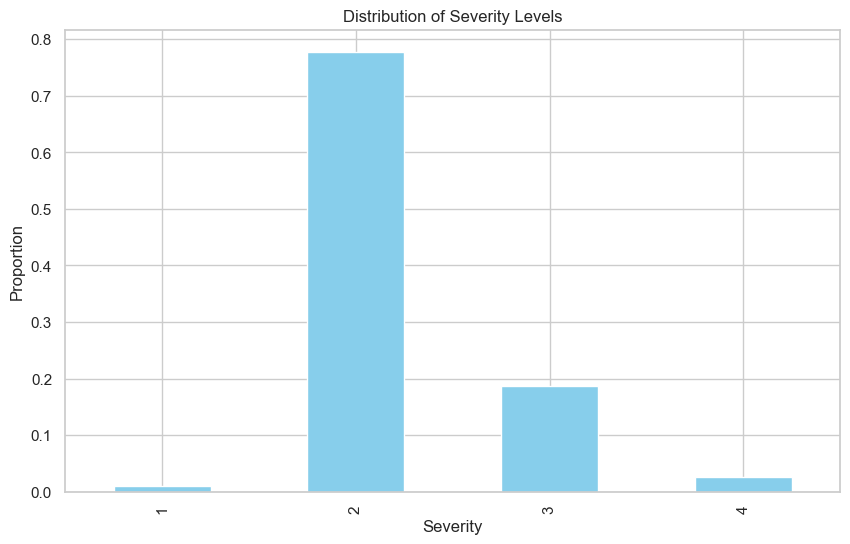

In [20]:
# Severity distribution
df["Severity"].value_counts(normalize=True).sort_index().plot(kind="bar", color="skyblue")
plt.xlabel("Severity")
plt.ylabel("Proportion")
plt.title("Distribution of Severity Levels")
plt.show()

In [21]:
# Descriptive statistics for derived/weather fields
df[["Duration_min"] + numeric_weather_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Duration_min,6985228.0,105.771008,123.178067,1.216667,30.00,62.15,121.983333,1440.00
Temperature(F),6985228.0,61.781660,18.378063,13.000000,50.00,64.00,75.900000,96.00
Wind_Chill(F),6985228.0,59.196069,18.567119,2.400000,52.00,62.00,70.000000,94.00
Humidity(%),6985228.0,65.095082,22.467873,12.000000,49.00,67.00,84.000000,100.00
Pressure(in),6985228.0,29.571903,0.922012,24.670000,29.41,29.87,30.030000,30.45
Visibility(mi),6985228.0,9.058103,2.299773,0.500000,10.00,10.00,10.000000,10.00
Wind_Speed(mph),6985228.0,7.607227,4.904322,0.000000,5.00,7.00,10.000000,23.00
Precipitation(in),6985228.0,0.003657,0.018240,0.000000,0.00,0.00,0.000000,0.14


In [22]:
# Export the cleaned and processed dataset to a new CSV file
output_path = "US_Accidents_March23_Cleaned.csv"
df.to_csv(output_path, index=False)

# 4. Analysis & Visualization

## When do accidents happen most?


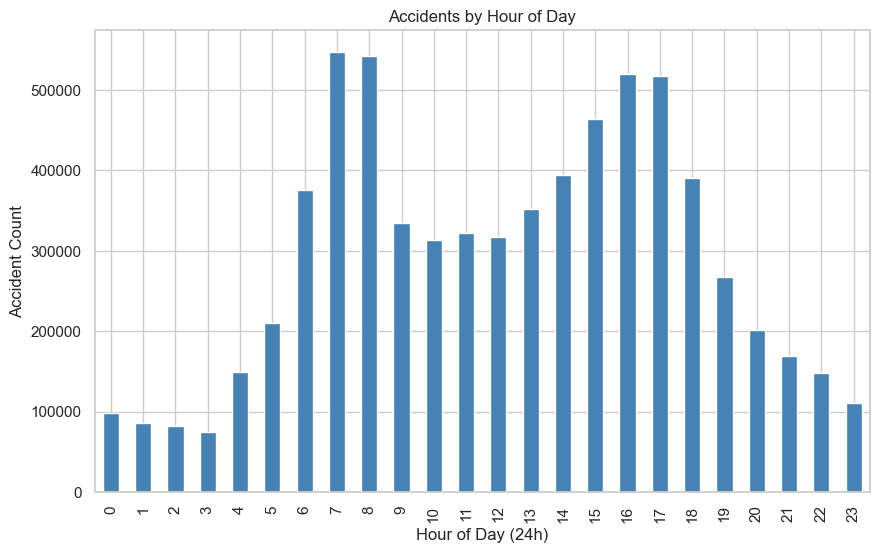

In [23]:
# Accidents by Hour of Day
df["Hour"].value_counts().sort_index().plot(kind="bar", color="steelblue")
plt.xlabel("Hour of Day (24h)")
plt.ylabel("Accident Count")
plt.title("Accidents by Hour of Day")
plt.show()

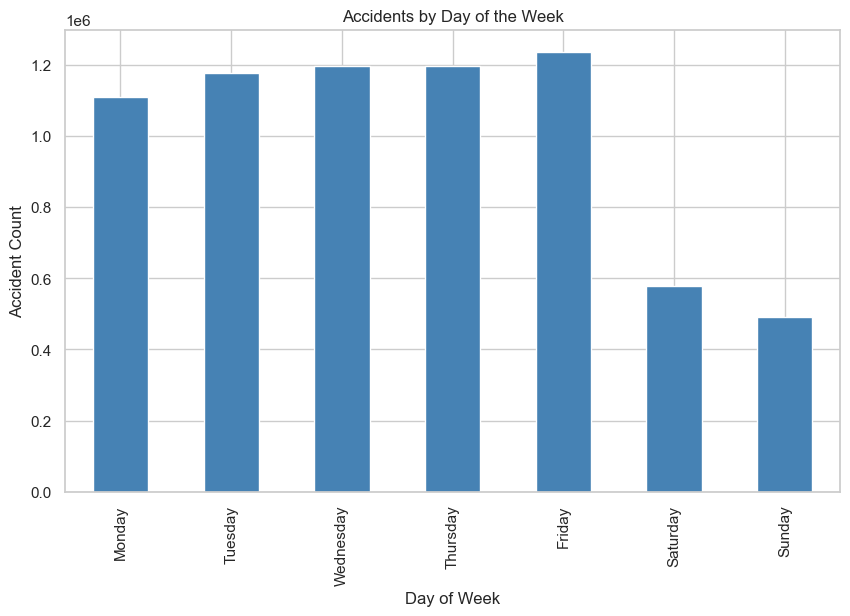

In [24]:
# Accidents by Day of Week
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df["DayOfWeek"].value_counts().reindex(day_order).plot(kind="bar", color="steelblue")
plt.xlabel("Day of Week")
plt.ylabel("Accident Count")
plt.title("Accidents by Day of the Week")
plt.show()

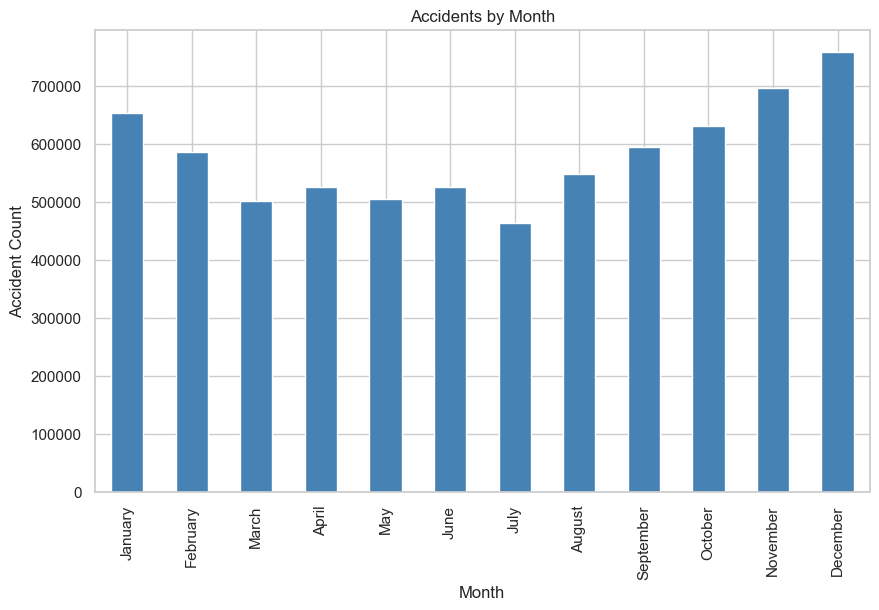

In [25]:
# Accidents by Month
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
df["Month_Name"].value_counts().reindex(month_order).plot(kind="bar", color="steelblue")
plt.xlabel("Month")
plt.ylabel("Accident Count")
plt.title("Accidents by Month")
plt.show()


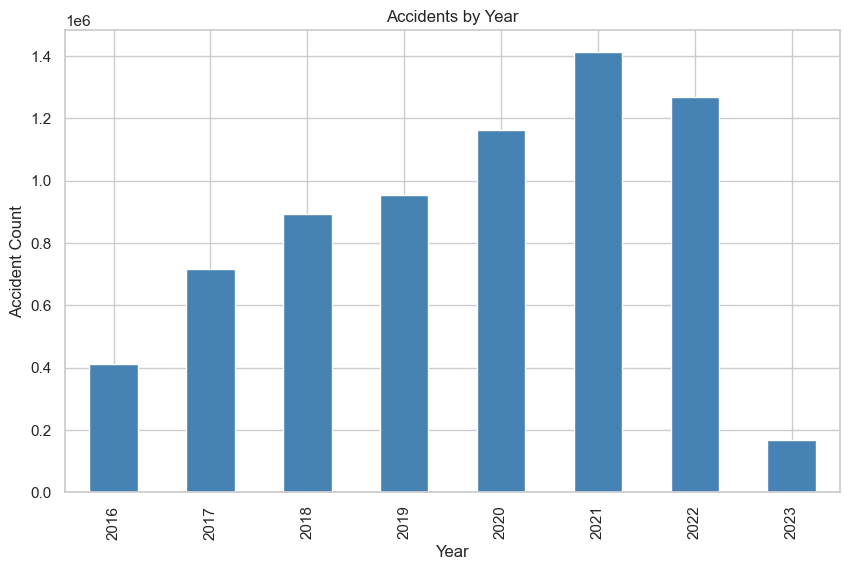

In [26]:
# Accidents by Year
df["Year"].value_counts().sort_index().plot(kind="bar", color="steelblue")
plt.xlabel("Year")
plt.ylabel("Accident Count")
plt.title("Accidents by Year")
plt.show()

#### Interpretation

Accident counts follow a clear bimodal pattern across the day, peaking sharply during the 7–8 AM and 4–6 PM commute windows, with the evening peak slightly broader than the morning one. Weekday volumes (Monday–Friday) are roughly double weekend volumes, and Friday is the single highest day, consistent with commute-driven traffic rather than random incident timing. Seasonally, accidents rise through the fall and peak in December/January before dropping to a summer low around June/July, pointing to a weather- and daylight-related seasonal effect layered on top of the daily commute pattern. Year-over-year counts climb steadily from 2016 through 2022 (with 2023 appearing artificially low only because that year's data ends in March), which most likely reflects the data source's expanding coverage over time rather than an actual multi-year rise in real-world accident rates.


## Where are accidents concentrated? (Geographically)

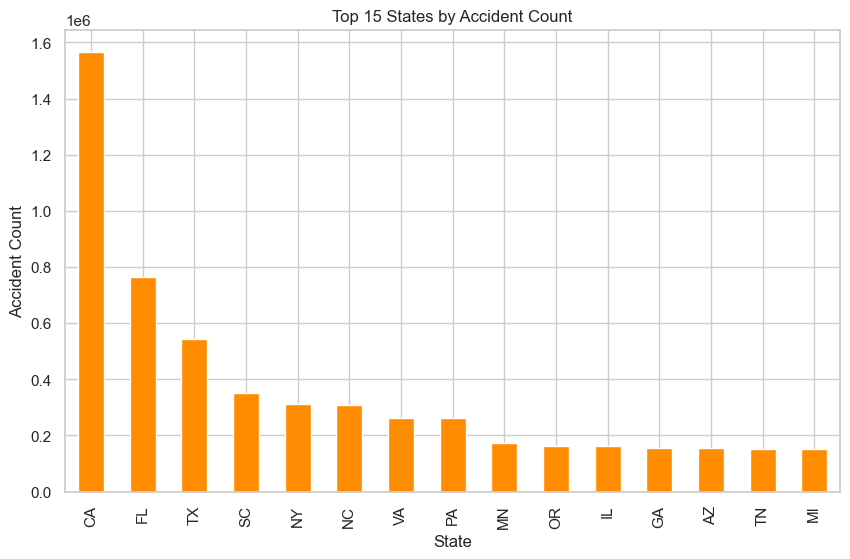

In [27]:
# Top 15 States by Accident Count
top15_states_count = df["State"].value_counts().head(15)

top15_states_count.plot(kind="bar", color="darkorange")
plt.xlabel("State")
plt.ylabel("Accident Count")
plt.title("Top 15 States by Accident Count")
plt.show()

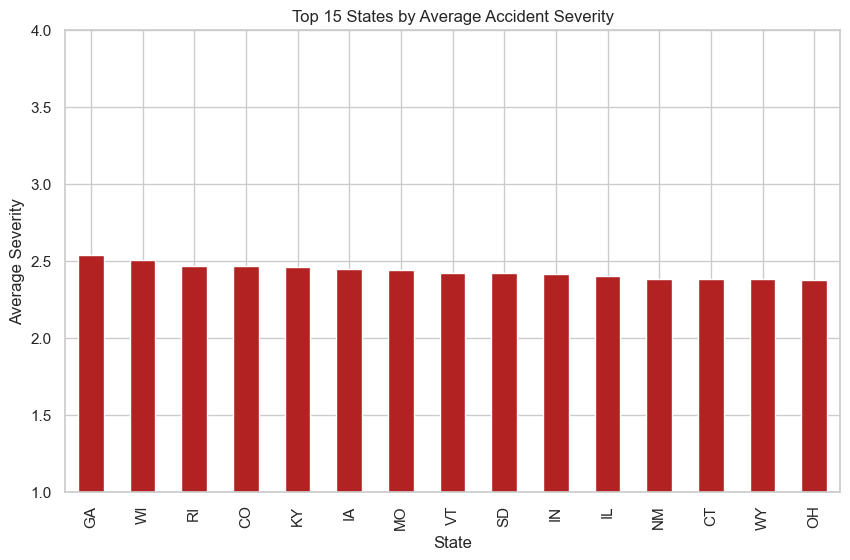

In [28]:
# Average Severity by State
avg_severity_by_state = df.groupby("State")["Severity"].mean().sort_values(ascending=False)
avg_severity_by_state.head(15)

# Top 15 States by Average Accident Severity
avg_severity_by_state.head(15).plot(kind="bar", color="firebrick")
plt.xlabel("State")
plt.ylabel("Average Severity")
plt.title("Top 15 States by Average Accident Severity")
plt.ylim(1, 4)
plt.show()

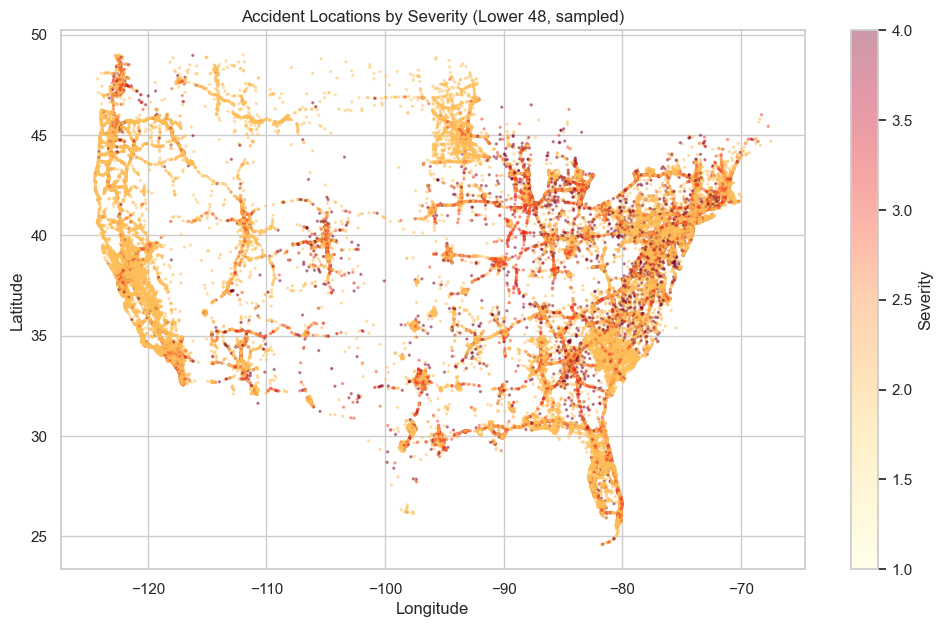

In [29]:
# Accident Locations by Severity
lower48 = df[(df["Start_Lat"].between(24, 50)) & (df["Start_Lng"].between(-125, -66))]
sample = lower48.sample(n=200_000, random_state=42)

plt.figure(figsize=(12, 7))
scatter = plt.scatter(sample["Start_Lng"], sample["Start_Lat"], c=sample["Severity"],
                       cmap="YlOrRd", s=2, alpha=0.4)
plt.colorbar(scatter, label="Severity")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Accident Locations by Severity (Lower 48, sampled)")
plt.show()

#### Interpretation

Raw accident counts are heavily concentrated in a handful of high-population, high-traffic states — California alone accounts for roughly a quarter of all records, far ahead of Florida and Texas — but this ranking is confounded by both population size and how heavily each state's traffic agencies feed data into the source APIs behind this dataset, so it reflects reporting volume as much as underlying risk. Average severity tells a different and arguably more useful story: states like Georgia, Wisconsin, and Rhode Island rank highest on average severity despite not being top-volume states, suggesting that when accidents do happen there, they tend to be more serious — possibly reflecting differences in road types (more highway miles relative to urban arterial), speed limits, or how severity is scored by the local reporting agency. The geographic scatter shows accidents heavily clustered along interstate corridors and around major metro areas (the outline of the interstate highway system is clearly visible), with higher-severity points appearing scattered throughout rather than concentrated in any one region, indicating that severity is driven more by road-level or situational factors than by broad geography alone.

## What drives severity? 

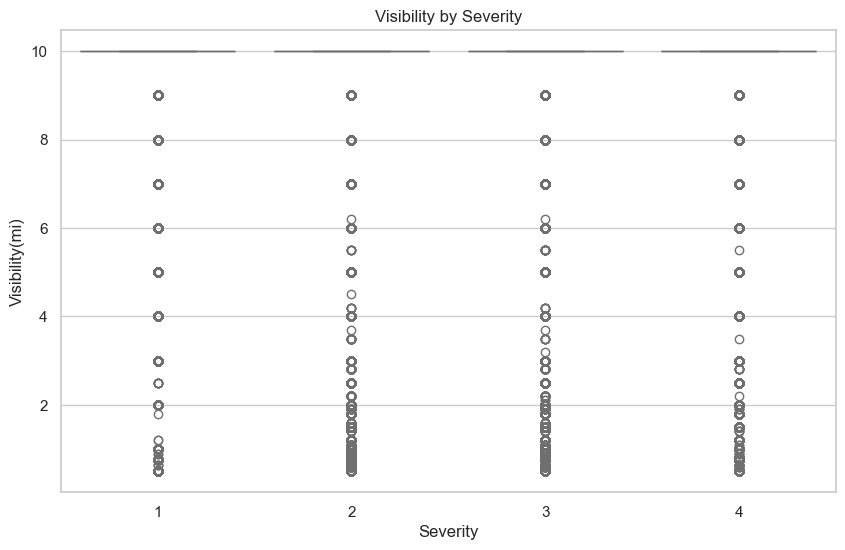

In [30]:
# Visibility by Severity
sns.boxplot(data=df, x="Severity", y="Visibility(mi)", color="skyblue")
plt.title("Visibility by Severity")
plt.show()

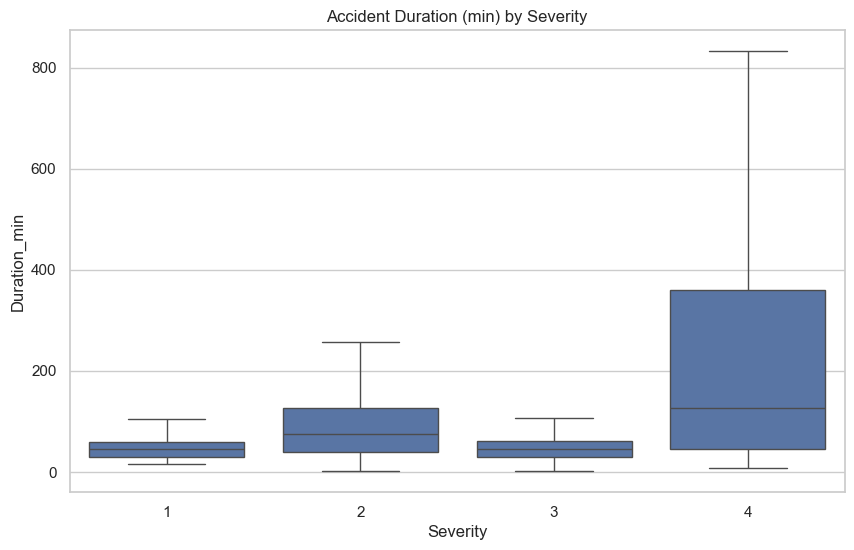

In [31]:
# Accident Duration (min) by Severity
sns.boxplot(data=df, x="Severity", y="Duration_min", showfliers=False)
plt.title("Accident Duration (min) by Severity")
plt.show()

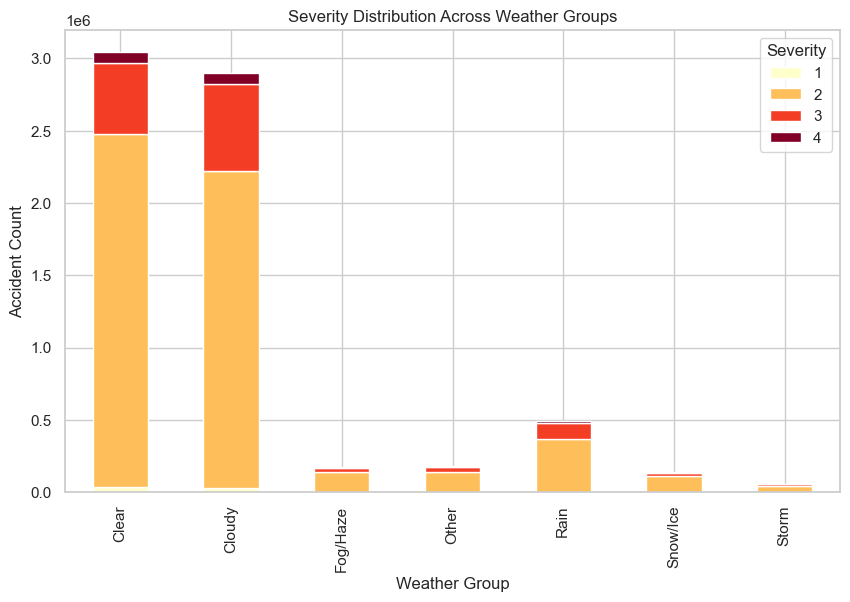

In [32]:
# Severity Distribution Across Weather Groups
weather_severity_counts = df.groupby(["Weather_Group", "Severity"]).size().unstack(fill_value=0)

weather_severity_counts.plot(kind="bar", stacked=True, colormap="YlOrRd")
plt.xlabel("Weather Group")
plt.ylabel("Accident Count")
plt.title("Severity Distribution Across Weather Groups")
plt.legend(title="Severity")
plt.show()

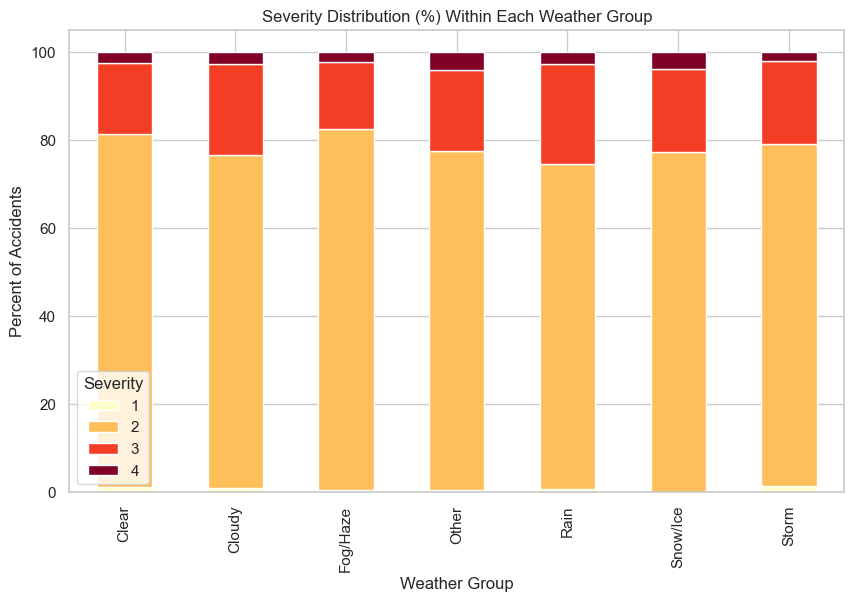

In [33]:
# Severity Distribution (%) Within Each Weather Group
weather_severity_pct = weather_severity_counts.div(weather_severity_counts.sum(axis=1), axis=0) * 100

weather_severity_pct.plot(kind="bar", stacked=True, colormap="YlOrRd")
plt.xlabel("Weather Group")
plt.ylabel("Percent of Accidents")
plt.title("Severity Distribution (%) Within Each Weather Group")
plt.legend(title="Severity")
plt.show()

#### Interpretation

Visibility shows only a small difference across severity levels — median visibility stays near 10 miles for every severity class — which suggests that poor visibility alone is not a strong standalone predictor of severity, likely because low-visibility conditions also cause drivers to slow down and compensate. Duration behaves less predictably: Severity 4 (most severe) accidents take noticeably longer to clear, as expected, but Severity 2 accidents actually show a longer median duration than Severity 3 — a mismatch between "how severe" an accident is coded and "how long" it disrupts traffic. When accidents are grouped by broad weather category, the percentage breakdown shows Rain and Snow/Ice conditions carry a modestly higher share of Severity 3–4 accidents compared to Clear conditions, while Fog/Haze — despite the visibility concern — does not stand out as more severe than Clear weather. Overall, weather condition appears to have a real but secondary effect on severity, and duration is better explained by traffic disruption/logistics than by severity level alone

# Which road features are associated with elevated risk?

## Road Feature Severity Comparison

In [34]:
road_features = ["Amenity", "Bump", "Crossing", "Give_Way", "Junction", "No_Exit",
                  "Railway", "Roundabout", "Station", "Stop", "Traffic_Calming",
                  "Traffic_Signal", "Turning_Loop"]

rows = []
for feature in road_features:
    present = df.loc[df[feature] == True, "Severity"]
    absent = df.loc[df[feature] == False, "Severity"]
    rows.append({
        "road_feature": feature,
        "avg_severity_present": present.mean(),
        "avg_severity_absent": absent.mean(),
        "count_present": present.shape[0]
    })

road_feature_severity = pd.DataFrame(rows).set_index("road_feature")
road_feature_severity.sort_values("avg_severity_present", ascending=False)

,avg_severity_present,avg_severity_absent,count_present
road_feature,,,
Junction,2.321503,2.221819,520602
Give_Way,2.183919,2.229472,34276
Railway,2.167489,2.229798,61628
Traffic_Calming,2.138828,2.229337,6843
No_Exit,2.120886,2.229524,17744
Bump,2.105331,2.229303,3114
Traffic_Signal,2.091059,2.254749,1088203
Station,2.081712,2.233190,181785
Stop,2.077841,2.233587,194589


## Average Severity When Road Feature is Present

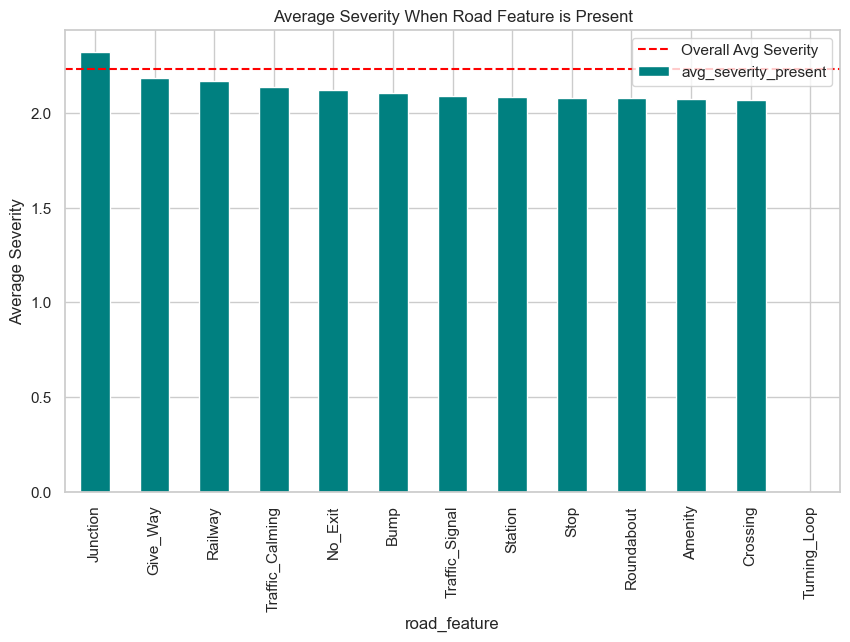

In [35]:
road_feature_severity.sort_values("avg_severity_present", ascending=False)["avg_severity_present"].plot(
    kind="bar", color="teal")
plt.axhline(df["Severity"].mean(), color="red", linestyle="--", label="Overall Avg Severity")
plt.ylabel("Average Severity")
plt.title("Average Severity When Road Feature is Present")
plt.legend()
plt.show()

#### Interpretation

The results run counter to a naive assumption that road features like traffic signals, crossings, and stop signs would be associated with *more* severe accidents. Instead, nearly every controlled road feature (`Traffic_Signal`, `Crossing`, `Stop`, `Station`, `Roundabout`) shows *lower* average severity when present compared to when absent — only `Junction` shows a (small) increase. The most plausible explanation is confounding by road type and speed: controlled features are concentrated on lower-speed urban and arterial roads where accidents are more frequent but less damaging, while their absence is more common on higher-speed highways and rural roads, where accidents are rarer but far more severe when they occur. `Turning_Loop` has effectively zero occurrences in the data and should be excluded from any modeling — it's a data sparsity issue rather than a real signal. This suggests any severity model should control for road/speed context (or use `Junction` cautiously) rather than treating road-feature presence as a direct causal risk factor.

# Surpising / Counterintuitive Findings

- **Controlled intersections show *lower* average severity, not higher.** `Traffic_Signal`, `Crossing`, and `Stop` all show reduced average severity when present — the opposite of what a naive "more infrastructure near an intersection = more danger" assumption would predict. This is very likely a road-type/speed confound (see 4.4) rather than these features actually making accidents worse.

- **Fog/Haze is not more severe than Clear weather**, despite the obvious visibility risk. Rain and Snow/Ice show a higher share of severe accidents, but Fog/Haze essentially matches Clear conditions — possibly because drivers self-regulate speed more heavily in fog than in rain or snow.

- **Severity 2 accidents last longer on average than Severity 3 accidents.** Duration does not increase monotonically with severity — Severity 4 is the clear outlier for long clearance times, but 2 vs. 3 is inverted, suggesting `Duration_min` reflects traffic/logistics disruption as much as it reflects how serious the accident itself was.

- **Visibility barely differs across severity levels** — median visibility is ~10 miles for every severity class, indicating that, in isolation, low visibility is a weak predictor of severity once other factors are considered.

- **California's #1 rank by volume does not carry over to severity.** States with far fewer total accidents (Georgia, Wisconsin, Rhode Island) rank higher on *average* severity, reinforcing that raw accident counts mostly reflect population/traffic volume and data-source density rather than underlying danger per accident.


# 5. Evaluation

## Business Insights/Recommendations

### 1: Concentrate enforcement and dynamic traffic management during weekday commute hours.

**Data Support**
Accident counts are sharply bimodal, peaking at **7–8 AM** and **4–6 PM**, with weekday volume roughly double weekend volume and Friday the single highest day.

**Action**
Shift patrol schedules, tow/incident-response staffing, and dynamic message signs (variable speed limits, congestion warnings) to concentrate resources in the two daily commute windows on weekdays, rather than spreading them evenly across the day.

**Potential Impact**
Roughly 40% of all recorded accidents cluster into these commute hours — even modest reductions here would move the needle on total accident counts more than an equivalent effort spread evenly across the day.

**Tracking Metrics**
- Accidents per commute-hour window (week-over-week)
- Average `Duration_min` during commute windows
- Secondary-collision rate (accidents occurring within X minutes/miles of a prior one)

**Challenges / Limitations**
Requires reallocating existing staff rather than adding headcount, which may face scheduling constraints. The data can't distinguish whether an intervention prevented accidents or just reduced their severity/duration — both need separate tracking.

### 2: Prioritize safety infrastructure on high-speed roads lacking traffic controls, not urban intersections.

**Data Support**
Counterintuitively, roads *with* traffic signals, crossings, or stop signs show **lower** average severity than roads without them *(Section 4.4)*. This points to uncontrolled, higher-speed roads — highways, rural routes — as the real severity driver, not intersections themselves.

**Action**
Redirect infrastructure investment (rumble strips, median barriers, speed cameras, lighting) toward high-speed corridors currently lacking traffic control features, rather than adding more signals/crossings in already-controlled urban areas.

**Potential Impact**
Targets accidents most likely to be serious, since severity — not just frequency — is concentrated on these uncontrolled segments.

**Tracking Metrics**
- Severity 3–4 accident rate per mile, treated vs. untreated segments
- Serious-injury proxy rate (Severity 4 as closest available proxy)
- Cost per severity-point reduction

**Challenges / Limitations**
This is an association from observational data, not a controlled experiment — speed limit and traffic volume weren't directly available, so this should be validated against local DOT speed data before committing capital spend. Rural infrastructure projects also tend to have longer lead times and higher per-mile costs.

### 3: Deploy weather-responsive road treatment for rain/snow — not a blanket low-visibility response.

**Data Support**
Rain and Snow/Ice conditions show a modestly higher share of Severity 3–4 accidents than Clear weather, and accident frequency rises through winter months. Notably, Fog/Haze does **not** show elevated severity despite the visibility concern — the response needs to be weather-type-specific.

**Action**
Prioritize proactive winter maintenance (pre-treatment/salting) and rain/snow-specific driver alerts on routes with historically high winter accident volume, rather than treating all low-visibility conditions the same.

**Potential Impact**
Targets the specific weather categories statistically linked to more severe outcomes, avoiding wasted resources on conditions — like fog — that this data doesn't show elevate severity.

**Tracking Metrics**
- Severity 3–4 rate per rain/snow-day
- `Duration_min` for rain/snow-related incidents (disruption proxy)
- Year-over-year change in winter-month severity share

**Challenges / Limitations**
Weather categorization here is a simplified bucket built from free-text descriptions, which can mask sub-conditions (e.g., black ice vs. light snow). Effectiveness also depends on reliable forecast lead time to pre-treat roads.



### [Tableau Dashboard link](https://public.tableau.com/app/profile/eric.bowers/viz/USTrafficAnalysisDashboardFINAL/Main)

(https://public.tableau.com/app/profile/eric.bowers/viz/USTrafficAnalysisDashboardFINAL/Main)

# Conclusion and Next Steps

## Tableau Data Export (Condensed)

### Condensed Accident Summary
Grouped by every dimension actually used across the dashboard's non-map worksheets (`Year`, `Month`, `Month_Name`, `DayOfWeek`, `State`, `Weather_Group`, `Severity`). `Hour` is deliberately left out — it's already served by the separate `tableau_hour_dow.csv`.

Tested on the full dataset: this drops row count from ~6.98M to **~215K rows (a 97% reduction)**.

In [36]:
summary_cols = ["Year", "Month", "Month_Name", "DayOfWeek", "State", "Weather_Group", "Severity"]

tableau_accidents_summary = df.groupby(summary_cols, observed=True).agg(
    accident_count=("ID", "count"),
    sum_visibility=("Visibility(mi)", "sum"),
    sum_duration_min=("Duration_min", "sum")
).reset_index()

tableau_accidents_summary.to_csv("tableau_accidents_summary.csv", index=False)
print("Rows:", len(tableau_accidents_summary))

Rows: 211116


### Condensed Map Grid


In [37]:
bin_size = 0.1

df["lat_bin"] = (df["Start_Lat"] / bin_size).round() * bin_size
df["lng_bin"] = (df["Start_Lng"] / bin_size).round() * bin_size

tableau_map_grid = df.groupby(["lat_bin", "lng_bin", "Severity", "State"]).size().reset_index(name="accident_count")

tableau_map_grid.to_csv("tableau_map_grid.csv", index=False)
print("Rows:", len(tableau_map_grid))

Rows: 70535


### State-level summary, hour/day grid, and road features

In [38]:
state_summary = df.groupby("State").agg(
    accident_count=("ID", "count"),
    avg_severity=("Severity", "mean"),
    pct_severity_3_4=("Severity", lambda s: (s >= 3).mean() * 100)
).reset_index()
state_summary.to_csv("tableau_state_summary.csv", index=False)

hour_dow = df.groupby(["DayOfWeek", "Hour"]).size().reset_index(name="accident_count")
hour_dow.to_csv("tableau_hour_dow.csv", index=False)

road_feature_severity.reset_index().to_csv("tableau_road_features.csv", index=False)

print("State summary rows:", len(state_summary))
print("Hour/day grid rows:", len(hour_dow))
print("Road feature rows:", len(road_feature_severity))

State summary rows: 49
Hour/day grid rows: 168
Road feature rows: 13


### Road Feature Severity Breakdown — All States

In [39]:
road_features = ["Amenity", "Bump", "Crossing", "Give_Way", "Junction", "No_Exit",
                  "Railway", "Roundabout", "Station", "Stop", "Traffic_Calming",
                  "Traffic_Signal", "Turning_Loop"]

rows = []
for state in sorted(df["State"].unique()):
    state_df = df[df["State"] == state]
    state_total = len(state_df)
    for feature in road_features:
        present = state_df.loc[state_df[feature] == True, "Severity"]
        absent = state_df.loc[state_df[feature] == False, "Severity"]
        rows.append({
            "State": state,
            "State Total Accidents": state_total,
            "Road Feature": feature,
            "Avg Severity (Present)": present.mean(),
            "Avg Severity (Absent)": absent.mean(),
            "Difference": present.mean() - absent.mean(),
            "Count Present": present.shape[0],
            "% of State's Accidents": round(present.shape[0] / state_total * 100, 2) if state_total > 0 else 0
        })

road_features_all_states = pd.DataFrame(rows)
road_features_all_states.to_csv("tableau_road_features_all.csv", index=False)

print(road_features_all_states.shape)
road_features_all_states.head()

(637, 8)


,State,State Total Accidents,Road Feature,Avg Severity (Present),Avg Severity (Absent),Difference,Count Present,% of State's Accidents
0,AL,95890,Amenity,2.130137,2.251689,-0.121552,292,0.30
1,AL,95890,Bump,NaN,2.251319,NaN,0,0.00
2,AL,95890,Crossing,2.074393,2.255042,-0.180649,1976,2.06
3,AL,95890,Give_Way,2.016376,2.255895,-0.239520,1832,1.91
4,AL,95890,Junction,2.350618,2.246853,0.103765,4127,4.30


### Files exported
| File | Rows (approx.) | Used for |
|---|---|---|
| `tableau_accidents_summary.csv` | ~215K | trend line, severity mix, accidents by month/year, visibility/duration by severity |
| `tableau_map_grid.csv` | ~72K | Point/density map |
| `tableau_state_summary.csv` | <60 | Top 15 states by count/severity |
| `tableau_hour_dow.csv` | <168 | Hour x Day  |
| `tableau_road_features_all.csv.csv` | 637 | Road feature visualizations |




